In [31]:
import pandas as pd
import numpy as np
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


In [32]:
#load the medical data
df = pd.read_csv('/home/selowa-mphadi/PycharmProjects/pythonProject/old projects/projects/Personal Projects/insurance.csv')


In [33]:
#display the first and last 5 rows for inspection
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [34]:
df.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


In [35]:
#basic shape, data type inspection
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [36]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


the dataset contains 1338 rows and 7 columns, with no missing values. 3 categorical columns were identified and  will later be encoded before modelling. 4 numerical columns identified and there is a need to check for skewness, outliers and scale using approriate scaler.

Insights

Age is well-distributed and symmetric, making it a stable and reliable feature with no major outlier concerns.

BMI shows a slight right skew with some extreme high values, indicating potential health-risk outliers.

Children is a discrete, low-range feature (mostly 0–2), suggesting limited variability and likely weaker predictive power.

Charges (target) is heavily right-skewed with very high variance, meaning a small group of individuals drives a large portion of costs.

Presence of outliers in both BMI and charges suggests potential non-linear relationships and sensitivity in modeling.

✅ Recommendations

Transform the target variable (charges) using a log transformation to reduce skewness and improve model performance.

Handle outliers carefully:

Investigate extreme values rather than blindly removing them

Consider robust models (e.g., tree-based algorithms)

Feature engineering:

Bin BMI into categories (e.g., normal, overweight, obese)

Treat children as a categorical/ordinal feature

Modeling strategy:

Avoid relying solely on linear models due to skewness and non-linearity

Use models like Random Forest or Gradient Boosting

Further EDA:

Analyze relationships between age, BMI, and charges

Identify drivers of high-cost cases (e.g., extreme BMI segments)

In [37]:
#univariate analysis to check for distributions and identify skewness
num_cols = df.select_dtypes(include='number').columns
cat_cols = df.select_dtypes(include='object').columns

for col in num_cols:
    # Histogram
    fig_hist = px.histogram(
           df,
           x=col,
           nbins=30,
           title=f"Distribution of {col}",
           marginal="box"  # adds boxplot on top
    )
    fig_hist.show()




In [38]:
#univariate analysis for categorical columns
for col in cat_cols:
    # Count plot (bar chart)
    value_counts = df[col].value_counts().reset_index()
    value_counts.columns = [col, "count"]

    fig_bar = px.bar(
        value_counts,
        x=col,
        y="count",
        title=f"Count Plot of {col}"
    )
    fig_bar.show()

In [46]:
#bivariate analysis (check the relationship between inputs and target column)
for col in num_cols:
    fig = px.scatter(
        df,
        x=col,
        y=df['charges'],
        #trendline="ols",  # adds regression line
        title=f"{col} vs {'Medical charges'}"
    )
    fig.show()

In [40]:
for col in cat_cols:
    fig = px.box(
        df,
        x=col,
        y=df['charges'],
        title=f"{'Medical charges'} by {col}"
    )
    fig.show()

In [41]:
for col in cat_cols:
    fig = px.violin(
        df,
        x=col,
        y=df['charges'],
        box=True,
        points="all",
        title=f"{'Medical charges'} distribution by {col} (Violin)"
    )
    fig.show()

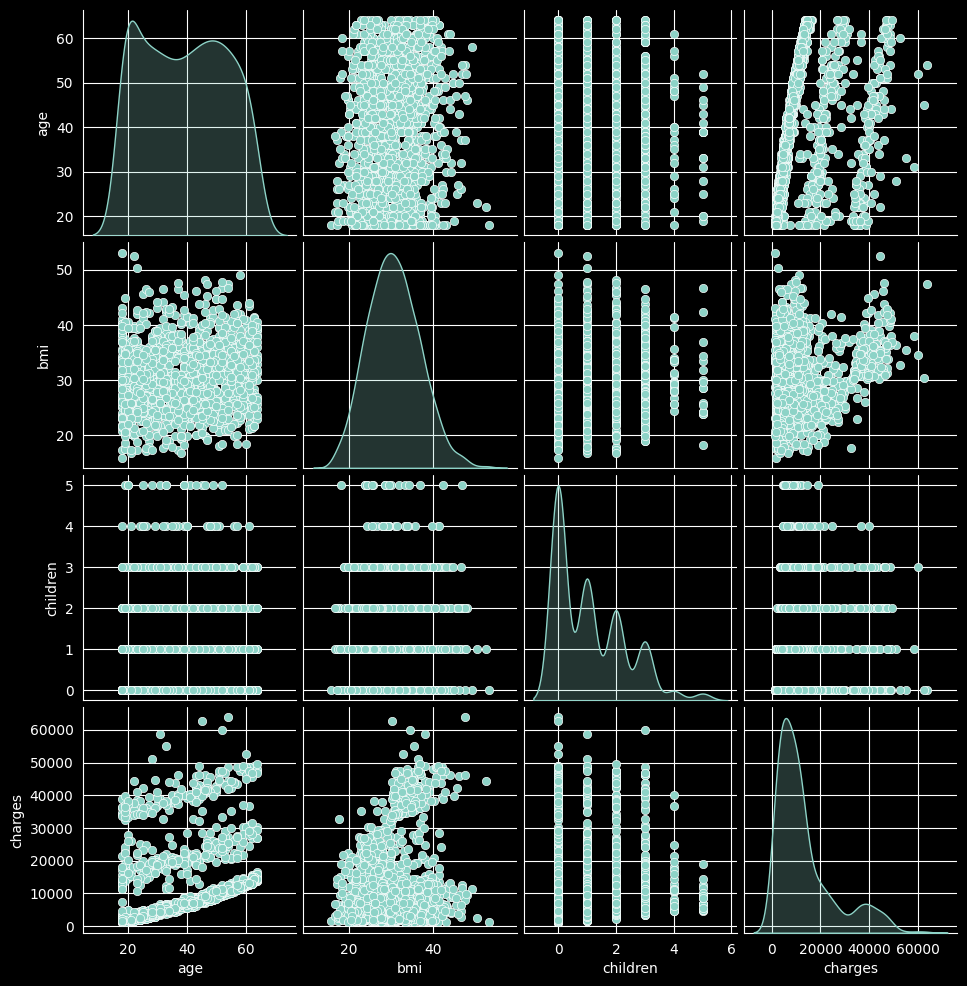

In [42]:
#correlation analysis
sns.pairplot(
    df,
    diag_kind="kde"  # smoother distribution on diagonal
)

plt.show()


In [43]:
import plotly.figure_factory as ff

# Select only numerical columns
num_df = df.select_dtypes(include='number')

# Compute correlation matrix
corr = num_df.corr()

# Create annotated heatmap
fig = ff.create_annotated_heatmap(
    z=corr.values,
    x=list(corr.columns),
    y=list(corr.columns),
    colorscale="Viridis",
    showscale=True
)

fig.update_layout(
    title="Correlation Heatmap",
    xaxis_title="Features",
    yaxis_title="Features"
)

fig.show()

In [44]:
target = "charges"

for col in num_cols:
    if col != target:
        fig = px.scatter(
            df,
            x=col,
            y=target,
            color="sex",
            facet_col="region",
            title=f"{col} vs {target} by Sex and Region"
        )
        fig.show()

In [45]:
for col in num_cols:
    if col != target:
        fig = px.scatter(
            df,
            x=col,
            y=target,
            color="smoker",        # smoker vs non-smoker
            facet_col="region",    # split by region
            facet_row="sex",       # split by sex
            title=f"{col} vs {target} by Sex, Region, and Smoker"
        )
        fig.show()